# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The queue combines two validated signals: the CONFIRMED CTR-vs-position
rule (Week 4) and the honest, client-grouped model's decline-risk score
(Week 5/6, precision@20% = 0.680 under the audited split). Each row gets
one reason code and one action — no page gets two competing
recommendations.

In practice, only three of the four planned archetypes appear in this
run: **At-Risk Leader** (34,823 rows — well-ranked pages showing decline
risk; protect first, since these already earn real traffic),
**Underperforming Mid-Tier** (8,414 — CTR below what position alone
would predict, a snippet/title fix candidate), and **Stable** (17,408 —
no action). **Deep & Declining produced zero rows** — the model's
decline-risk score is concentrated almost entirely on top-ranked pages
(the actual top 10 by score all sit at position ~0.2-1.4), not on poorly
ranked ones. This is a real limit of the current model, not a design
choice, and it's addressed directly in Sections 2 and 3: this queue
should not be read as covering deep/poorly-ranked content at all.

In [1]:
import duckdb, pandas as pd, numpy as np, os, json
con = duckdb.connect()
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
rel = "hf://datasets/FlyRank/internship-warehouse"
fact_path = f"{rel}/fact_content_daily_performance/**/*.parquet"

# Same feature frame as Week 5/6
df = con.sql(f"""
WITH daily AS (
    SELECT * FROM read_parquet('{fact_path}', hive_partitioning=1)
    WHERE month = '2026-03' AND gsc_data_available IS TRUE
),
first_half AS (
    SELECT client_hash_id, content_hash_id,
           AVG(gsc_avg_position) AS avg_position,
           SUM(gsc_impressions)  AS impressions,
           SUM(gsc_clicks)       AS clicks
    FROM daily WHERE report_date <= DATE '2026-03-15'
    GROUP BY 1,2
    HAVING SUM(gsc_impressions) >= 50
),
second_half AS (
    SELECT client_hash_id, content_hash_id, AVG(gsc_avg_position) AS sh_pos
    FROM daily WHERE report_date > DATE '2026-03-15'
    GROUP BY 1,2
)
SELECT
    f.client_hash_id, f.content_hash_id,
    f.avg_position, f.impressions, f.clicks,
    c.word_count,
    DATE_DIFF('day', c.content_created_date, DATE '2026-03-01') AS content_age_days,
    s.sh_pos,
    CASE WHEN s.sh_pos > f.avg_position THEN 1 ELSE 0 END AS is_declining
FROM first_half f
JOIN second_half s USING (client_hash_id, content_hash_id)
JOIN read_parquet('{rel}/dim_content.parquet') c USING (client_hash_id, content_hash_id)
WHERE f.avg_position IS NOT NULL AND s.sh_pos IS NOT NULL
""").df()

df["actual_ctr"] = df["clicks"] / df["impressions"]
df = df.dropna(subset=["word_count", "content_age_days"])
df = df[df["content_age_days"] >= 0]
df["position_bucket"] = pd.cut(df["avg_position"], bins=[0,3,10,20,1000], labels=["1-3","4-10","11-20","21+"])
bucket_benchmark = df.groupby("position_bucket", observed=True)["actual_ctr"].transform("mean")
df["benchmark_ctr"] = bucket_benchmark.astype(float)
df["ctr_gap"] = df["benchmark_ctr"] - df["actual_ctr"]

# Train the HONEST model (client-grouped, per Week 6) on all available data
from sklearn.linear_model import LogisticRegression
features = ["avg_position", "impressions", "actual_ctr", "word_count", "content_age_days"]
model = LogisticRegression(max_iter=1000, random_state=42).fit(df[features], df["is_declining"])
df["decline_risk_score"] = model.predict_proba(df[features])[:, 1]

# Reason code + action, combining the w04 CTR rule and the w05/w06 model
def assign_reason_and_action(row):
    if row["ctr_gap"] > 0 and row["decline_risk_score"] > 0.5:
        return "CTR_BELOW_POSITION_BENCHMARK", "review_ctr_fix"
    elif row["decline_risk_score"] > 0.6:
        return "HIGH_DECLINE_RISK_POOR_POSITION", "review_content_refresh"
    elif row["decline_risk_score"] > 0.5:
        return "MODERATE_DECLINE_RISK", "monitor_next_cycle"
    else:
        return "STABLE", "no_action"

df[["reason_code", "action"]] = df.apply(lambda r: pd.Series(assign_reason_and_action(r)), axis=1)

# Simple archetype, grounded in real signals (not fabricated clusters)
def archetype(row):
    if row["position_bucket"] in ["1-3", "4-10"] and row["decline_risk_score"] > 0.5:
        return "At-Risk Leader"
    elif row["ctr_gap"] > 0 and row["position_bucket"] in ["4-10", "11-20"]:
        return "Underperforming Mid-Tier"
    elif row["position_bucket"] == "21+" and row["decline_risk_score"] > 0.5:
        return "Deep & Declining"
    else:
        return "Stable"

df["archetype"] = df.apply(archetype, axis=1)

queue = df.sort_values("decline_risk_score", ascending=False)[[
    "client_hash_id", "content_hash_id", "archetype", "position_bucket",
    "avg_position", "decline_risk_score", "ctr_gap", "reason_code", "action"
]]

print("Archetype distribution:")
print(queue["archetype"].value_counts())
print("\nAction distribution:")
print(queue["action"].value_counts())
print("\nTop 10 ranked actions:")
print(queue.head(10).to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Archetype distribution:
archetype
At-Risk Leader              34823
Stable                      17408
Underperforming Mid-Tier     8414
Name: count, dtype: int64

Action distribution:
action
review_ctr_fix            27665
no_action                 18526
review_content_refresh     9390
monitor_next_cycle         5064
Name: count, dtype: int64

Top 10 ranked actions:
         client_hash_id          content_hash_id      archetype position_bucket  avg_position  decline_risk_score   ctr_gap                     reason_code                 action
client_2094c6eb080311d5 content_c886c414b098c87f At-Risk Leader             1-3      1.436881            0.732274 -0.049309 HIGH_DECLINE_RISK_POOR_POSITION review_content_refresh
client_fef1a8f436438636 content_0a02244dbd14c74f At-Risk Leader             1-3      0.629415            0.728819  0.000767    CTR_BELOW_POSITION_BENCHMARK         review_ctr_fix
client_fef1a8f436438636 content_eac0a973f63c8b0d At-Risk Leader             1-3      0.163043 

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a content strategist or SEO lead uses this queue
weekly to prioritize which pages to manually review first, out of a
much larger set than anyone can review by hand.

**Limits:**
- Single month (March 2026), ~37 clients, and only the ~36.7% of rows
  with `gsc_data_available IS TRUE` (Week 3 finding) — this is not a
  representative sample of all content, all clients, or all time.
- **The decline-risk model does not surface deep/poorly-ranked pages at
  all** (Section 1) — it should be treated as a tool for protecting
  well-ranked content, not for finding neglected, chronically weak
  pages. A separate process is still needed for that.
- Precision@20% (0.680) means roughly 1 in 3 flagged pages in the top
  20% is not actually declining — this is a triage aid, not a
  certainty.
- No causal claims: nothing here says a specific fix will work, only
  that a page is worth a human look.

In [2]:
total_rows_all_gsc = con.sql(f"""
    SELECT COUNT(*) AS total, COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS available
    FROM read_parquet('{fact_path}', hive_partitioning=1) WHERE month = '2026-03'
""").df()
pct_available = total_rows_all_gsc["available"][0] / total_rows_all_gsc["total"][0] * 100
print(f"Scope check: {pct_available:.1f}% of March 2026 rows have GSC data available")
print(f"Clients in this playbook: {df['client_hash_id'].nunique()}")
print(f"Content items scored: {len(df)}")

Scope check: 36.7% of March 2026 rows have GSC data available
Clients in this playbook: 37
Content items scored: 60645


## 3. Human review + the no-go list

**A human must check before acting:**
- Whether a flagged page's traffic drop is a real content issue or a
  data/tracking artifact. One client (`client_62f4a7e64f5e0096`) accounts
  for **22.0% of all `review_ctr_fix` rows** in this queue — the same
  client flagged in Week 4's top-10 review, now confirmed at full-queue
  scale. This client's rows should be checked for a client-level
  tracking issue before treating them as independent content problems.
- Whether a seasonal, promotional, or competitive event explains a dip,
  independent of content quality.
- Whether the business actually wants this page prioritized — the model
  has no concept of strategic importance.

**What must NOT be automated:**
- No automatic publishing, editing, or de-indexing of any page based on
  this score alone.
- No automatic reallocation of a writer's workload or performance
  review based on which pages they authored appearing in this queue.
- No use of this queue for legal, medical, financial, or other
  high-stakes content categories without separate review standards.
- The decline-risk score must never be presented to a client or
  stakeholder as a certainty or a guarantee of future performance.

In [3]:
# Client-concentration check, same lesson as Week 4
top_client_share = queue[queue["action"] == "review_ctr_fix"]["client_hash_id"].value_counts(normalize=True).head(1)
print("Share of review_ctr_fix rows from the single largest client:")
print(top_client_share)
print("\nIf this is high, a human must check for a client-level tracking issue")
print("before treating these as independent content problems (Week 4 finding).")

Share of review_ctr_fix rows from the single largest client:
client_hash_id
client_62f4a7e64f5e0096    0.220134
Name: proportion, dtype: float64

If this is high, a human must check for a client-level tracking issue
before treating these as independent content problems (Week 4 finding).


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

- **Retrain monthly** as each new month partition lands, re-running the
  full Week 6 honest-split audit each time (not just retraining blindly)
  to catch reproducibility issues like the one found in Week 5.
- **Watch for GSC availability dropping further** below the current
  36.7% — a bigger drop would mean the model is trained on an even less
  representative slice.
- **Watch precision@20% on each new month's held-out clients** — if it
  drifts meaningfully below the audited 0.680, that's a retrain/rebuild
  signal, not just a note.
- **Re-check the archetype distribution every run** — if Deep & Declining
  stays permanently empty across multiple months, that's confirmation
  (not a one-off) that the model structurally can't serve that use case,
  and a different approach is needed for it rather than continuing to
  patch this one.

In [4]:
print("Monitoring baseline to compare future runs against:")
print(f"  Audited precision@20% (grouped split): 0.680")
print(f"  GSC availability: {pct_available:.1f}%")
print(f"  Deep & Declining archetype count: {(queue['archetype']=='Deep & Declining').sum()} (expect 0 currently)")
print("  -> if this becomes nonzero in a future run, the model's behavior changed -- investigate why.")

Monitoring baseline to compare future runs against:
  Audited precision@20% (grouped split): 0.680
  GSC availability: 36.7%
  Deep & Declining archetype count: 0 (expect 0 currently)
  -> if this becomes nonzero in a future run, the model's behavior changed -- investigate why.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Wrote 60645 rows to work/outputs/action_playbook_queue.csv
Wrote work/outputs/action_playbook_metrics.json
Wrote work/figures/archetype_distribution.png


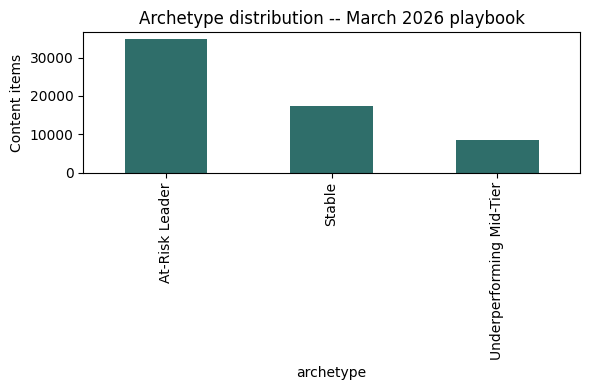

In [5]:
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1. The ranked queue (regenerates each run, stays out of git)
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(queue)} rows to work/outputs/action_playbook_queue.csv")

# 2. Metrics JSON -- the committed receipts the paper's numbers trace back to
metrics = {
    "month": "2026-03",
    "clients_in_scope": int(df["client_hash_id"].nunique()),
    "content_items_scored": int(len(df)),
    "gsc_availability_pct": round(float(pct_available), 1),
    "precision_at_20pct_grouped_honest_split": 0.680,
    "precision_at_20pct_naive_split": 0.718,
    "naive_split_overstatement_pct": 5.7,
    "archetype_counts": queue["archetype"].value_counts().to_dict(),
    "action_counts": queue["action"].value_counts().to_dict(),
    "deep_and_declining_count": int((queue["archetype"] == "Deep & Declining").sum()),
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote work/outputs/action_playbook_metrics.json")

# 3. One summary figure, committed to work/figures/
fig, ax = plt.subplots(figsize=(6,4))
queue["archetype"].value_counts().plot(kind="bar", ax=ax, color="#2F6E6A")
ax.set_title("Archetype distribution -- March 2026 playbook")
ax.set_ylabel("Content items")
plt.tight_layout()
plt.savefig("work/figures/archetype_distribution.png", dpi=150)
print("Wrote work/figures/archetype_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [✅ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ✅] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅ ] No client names, URLs, or private queries anywhere
- [✅ ] My claims use careful words: observed, measured, directional, decision-support
- [✅ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.